In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNetV2, EfficientNetB0
)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU available: []


In [ ]:
!pip install opendatasets -q
import opendatasets as od

od.download("https://www.kaggle.com/datasets/puneet6060/intel-image-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ap252143@gmail.com
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification


100%|██████████| 346M/346M [00:03<00:00, 98.5MB/s]


In [ ]:
# Set paths
data_dir = 'intel-image-classification'
train_dir = os.path.join(data_dir, 'seg_train', 'seg_train')
test_dir = os.path.join(data_dir, 'seg_test', 'seg_test')

class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"\nTraining samples per class:")
for c in class_names:
    count = len(os.listdir(os.path.join(train_dir, c)))
    print(f"  {c}: {count}")

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Training samples per class:
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382


In [ ]:
IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range=0.2,
    height_shift_range = 0.2,
    width_shift_range = 0.2,
    horizontal_flip=True,
    zoom_range = 0.2,
    validation_split = 0.2
)

test_datasetgen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

test_generator = test_datasetgen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\nTrain: {train_generator.samples}")
print(f"Val: {val_generator.samples}")
print(f"Test: {test_generator.samples}")

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

Train: 11230
Val: 2804
Test: 3000


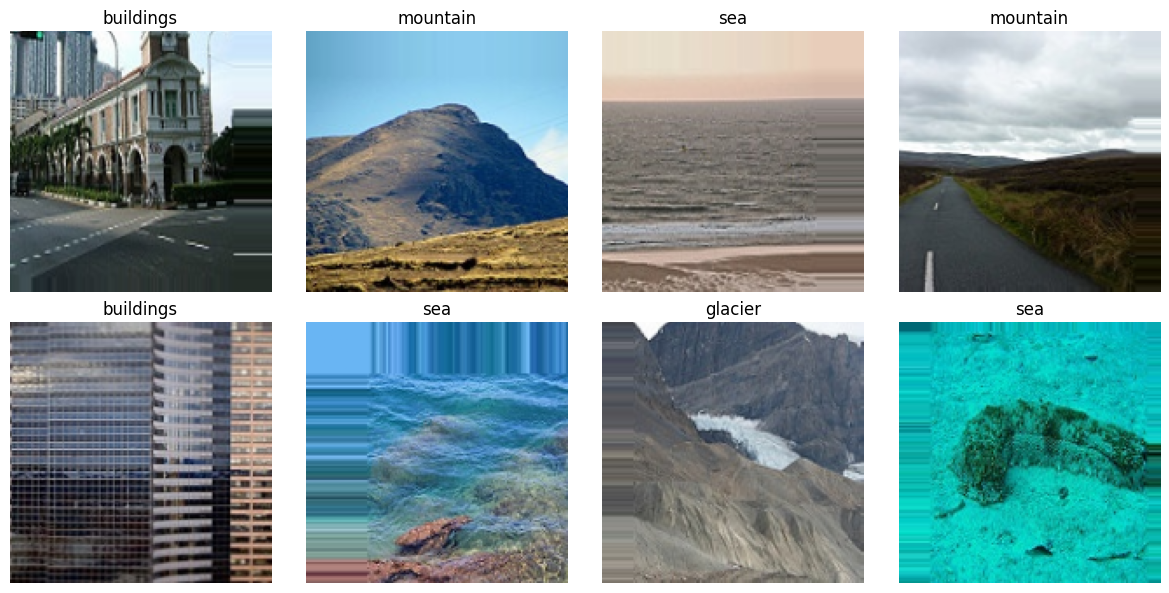

In [ ]:
# Visualize samples
def show_batch(generator, class_names):
    images, labels = next(generator)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.flatten()):
        if i < len(images):
            ax.imshow(images[i])
            label_idx = np.argmax(labels[i])
            ax.set_title(class_names[label_idx])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_batch(train_generator, class_names)

In [ ]:
# A Model from scratch
def build_model():
  model = models.Sequential([
      layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2, 2)),

      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2, 2)),

      layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2, 2)),

      layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
      layers.BatchNormalization(),
      layers.MaxPooling2D((2, 2)),

      layers.Flatten(),
      layers.Dense(512, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation='softmax')

  ])
  return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,010,758 (42.00 MB)

 Trainable params: 11,009,798 (42.00 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(factor=0.5, patience=3)

In [ ]:
model_results = model.evaluate(test_generator)
print(f"\nFrom Scratch - Test Accuracy: {model_results[1]:.2%}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 90s 945ms/step - accuracy: 0.1763 - loss: 1.7920

From Scratch - Test Accuracy: 17.63%


Transfer Learning: Feature Extraction

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

#Freezing the base model
base_model.trainable = False
print(f"Base Model: MobileNetV2")
print(f"Layers: {len(base_model.layers)}")
print(f"Trainable: {base_model.trainable}")

/tmp/ipykernel_21075/3038222509.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model: MobileNetV2
Layers: 154
Trainable: False


In [ ]:
#Building the transfer learning model
def build_transfer_model(base_model, num_classes):
  model = models.Sequential([
      base_model,
      layers.GlobalAveragePooling2D(),
      layers.Dense(256, activation='relu'),
      layers.Dropout(0.5),
      layers.Dense(num_classes, activation='softmax')
  ])
  return model

transfer_model = build_transfer_model(base_model, num_classes)
transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
#checking the trainable parameters
total_params = transfer_model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights])
non_trainable = total_params - trainable_params

print(f"Total params: {total_params}")
print(f"Trainable params: {trainable_params}")
print(f"Non-trainable params: {non_trainable}")

Total params: 2587462
Trainable params: 329478
Non-trainable params: 2257984


In [ ]:
#Compile
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 487s 1s/step - accuracy: 0.7977 - loss: 0.5535 - val_accuracy: 0.8680 - val_loss: 0.3586 - learning_rate: 0.0010
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step - accuracy: 0.8524 - loss: 0.3998 - val_accuracy: 0.8820 - val_loss: 0.3197 - learning_rate: 0.0010
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.8568 - loss: 0.3884 - val_accuracy: 0.8855 - val_loss: 0.3061 - learning_rate: 0.0010
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 362s 1s/step - accuracy: 0.8630 - loss: 0.3714 - val_accuracy: 0.8684 - val_loss: 0.3426 - learning_rate: 0.0010
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 367s 1s/step - accuracy: 0.8664 - loss: 0.3564 - val_accuracy: 0.8866 - val_loss: 0.2937 - learning_rate: 0.0010
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 386s 1s/step - accuracy: 0.8675 - loss: 0.3550 - val_accuracy: 0.8798 - val_loss: 0.3241 - learning_rate: 0.0010
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - accuracy: 0.8706 - loss: 0.

In [ ]:
transfer_results = transfer_model.evaluate(test_generator)
print(f"/n feature ectraction - test accuracy: {transfer_results[1]:.2%}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 59s 623ms/step - accuracy: 0.9047 - loss: 0.2559
/n feature ectraction - test accuracy: 90.47%


Fine Tuning

In [ ]:
base_model.trainable = True

#freezing all the layers except the last 30
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[: fine_tune_at]:
    layer.trainable = False

trainable_layers = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Fine-tuning last {trainable_layers} layers")

Fine-tuning last 30 layers


In [ ]:
#recompiling with a lower learning rate
transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - accuracy: 0.8560 - loss: 0.3926 - val_accuracy: 0.8969 - val_loss: 0.3410 - learning_rate: 1.0000e-04
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 473s 1s/step - accuracy: 0.8896 - loss: 0.3033 - val_accuracy: 0.8606 - val_loss: 0.4977 - learning_rate: 1.0000e-04
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.9033 - loss: 0.2693 - val_accuracy: 0.8787 - val_loss: 0.4221 - learning_rate: 1.0000e-04
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.9167 - loss: 0.2326 - val_accuracy: 0.9094 - val_loss: 0.3035 - learning_rate: 5.0000e-05
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 463s 1s/step - accuracy: 0.9211 - loss: 0.2215 - val_accuracy: 0.9108 - val_loss: 0.2866 - learning_rate: 5.0000e-05
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - accuracy: 0.9277 - loss: 0.1996 - val_accuracy: 0.9144 - val_loss: 0.2722 - learning_rate: 5.0000e-05
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 456s 1s/step - acc

In [ ]:
fine_tune_results = transfer_model.evaluate(test_generator)
print(f"Fine tuned - Test Accuracy: {fine_tune_results[1]:.2%}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 60s 635ms/step - accuracy: 0.9227 - loss: 0.2449
Fine tuned - Test Accuracy: 92.27%


Comparing different pretrained models

In [ ]:
# Compare architectures
def train_pretrained_model(base_model_class, name):
    print(f"\n{'='*50}")
    print(f"Training {name}...")
    print(f"{'='*50}")

    # Load base
    base = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    # Build model
    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5,
        verbose=1
    )

    # Evaluate
    results = model.evaluate(test_generator, verbose=0)
    print(f"{name} Test Accuracy: {results[1]:.2%}")

    return results[1], model

# Compare models
model_comparison = {}

models_to_test = [
    (VGG16, 'VGG16'),
    (ResNet50, 'ResNet50'),
    (EfficientNetB0, 'EfficientNetB0')
]

for model_class, name in models_to_test:
    acc, _ = train_pretrained_model(model_class, name)
    model_comparison[name] = acc


Training VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 3827s 11s/step - accuracy: 0.6921 - loss: 0.8148 - val_accuracy: 0.8039 - val_loss: 0.5321
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 3821s 11s/step - accuracy: 0.7911 - loss: 0.5620 - val_accuracy: 0.8167 - val_loss: 0.5062
Epoch 3/5
 62/351 ━━━━━━━━━━━━━━━━━━━━ 40:52 8s/step - accuracy: 0.8013 - loss: 0.5103

KeyboardInterrupt: 

In [ ]:
# Add previous results
model_comparison['From Scratch'] = scratch_results[1]
model_comparison['MobileNetV2 (fine-tuned)'] = fine_tune_results[1]

# Plot comparison
plt.figure(figsize=(10, 6))
names = list(model_comparison.keys())
accs = list(model_comparison.values())
colors = ['red' if 'Scratch' in n else 'steelblue' for n in names]

bars = plt.barh(names, accs, color=colors)
plt.xlabel('Test Accuracy')
plt.title('Model Comparison: From Scratch vs Transfer Learning')
plt.xlim(0, 1)

for bar, acc in zip(bars, accs):
    plt.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f'{acc:.1%}', va='center')

plt.tight_layout()
plt.show()